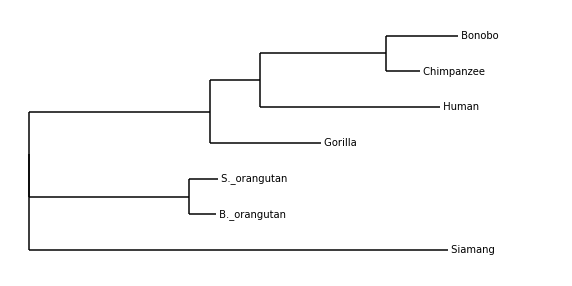

In [3]:
from Bio import Phylo
import matplotlib.pyplot as plt

def plot_newick_tree(newick_file, output_file):
    # Load the Newick tree
    tree = Phylo.read(newick_file, 'newick')

    # Create a smaller matplotlib figure
    fig, ax = plt.subplots(figsize=(10, 5))  # Adjusted size to fit within limits

    # Draw the tree using Phylo
    Phylo.draw(tree, do_show=False, axes=ax)

    # Beautify the plot
    plt.axis('off')  # Hide the axes
    plt.savefig(output_file, format='png')  # Save the plot to a file
    plt.show()

# Example usage
newick_file = 'tree_flanks500_0.8.nwk'
output_file = 'tree_plot.png'
plot_newick_tree(newick_file, output_file)

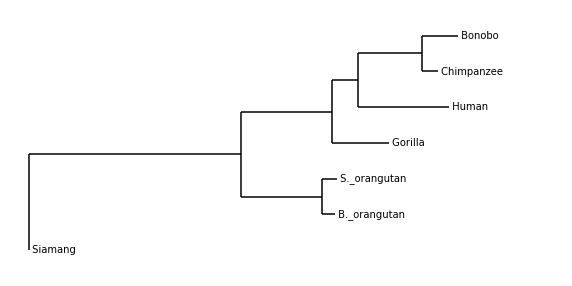

In [6]:
from Bio import Phylo
import matplotlib.pyplot as plt

def plot_rooted_newick_tree(newick_file, output_file, outgroup):
    # Load the Newick tree
    tree = Phylo.read(newick_file, 'newick')

    # Root the tree with the specified outgroup
    tree.root_with_outgroup(outgroup)

    # Create a matplotlib figure
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw the tree using Phylo
    Phylo.draw(tree, do_show=False, axes=ax)

    # Beautify the plot
    plt.axis('off')  # Hide the axes
    plt.savefig(output_file, format='png')  # Save the plot to a file
    plt.show()

# Example usage
newick_file = 'tree_flanks500_0.8.nwk'
output_file = 'tree_plot.png'
outgroup = 'Siamang'  # Replace with the actual outgroup name
plot_rooted_newick_tree(newick_file, output_file, outgroup)

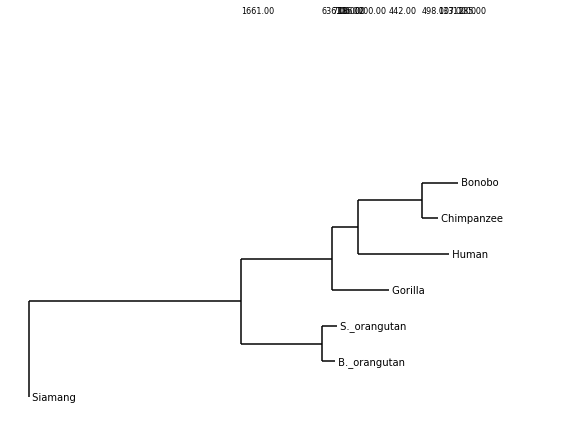

In [7]:
from Bio import Phylo
import matplotlib.pyplot as plt

def plot_rooted_newick_tree_with_lengths(newick_file, output_file, outgroup):
    # Load the Newick tree
    tree = Phylo.read(newick_file, 'newick')

    # Root the tree with the specified outgroup
    tree.root_with_outgroup(outgroup)

    # Create a matplotlib figure
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw the tree using Phylo and return the coordinates
    Phylo.draw(tree, do_show=False, axes=ax)
    
    # Get the x and y limits to adjust the positioning of labels
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()

    # Add branch length labels
    for clade in tree.find_clades():
        if clade.branch_length:
            # Calculate the position of the branch label
            x = tree.distance(clade)
            y = (ylims[1] - ylims[0]) * 0.5  # Centering on the y-axis (approximate)
            
            # Adjust y position relative to clade's position in the plot
            y_position = y + (clade.confidence if clade.confidence is not None else 0)

            # Add the branch length text at the appropriate position
            ax.text(x, y_position, f'{clade.branch_length:.2f}', 
                    verticalalignment='center', horizontalalignment='left', fontsize=8)

    # Beautify the plot
    plt.axis('off')  # Hide the axes
    plt.savefig(output_file, format='png')  # Save the plot to a file
    plt.show()

# Example usage
newick_file = 'tree_flanks500_0.8.nwk'
output_file = 'tree_plot.png'
outgroup = 'Siamang'  # Replace with the actual outgroup name
plot_rooted_newick_tree_with_lengths(newick_file, output_file, outgroup)

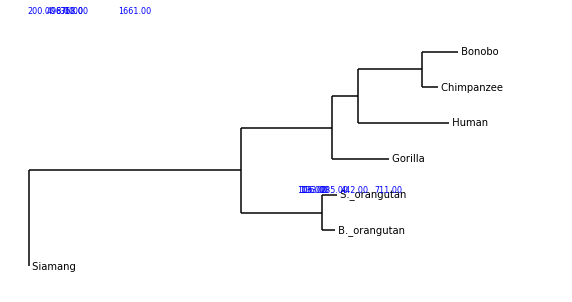

In [8]:
from Bio import Phylo
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_rooted_newick_tree_with_lengths(newick_file, output_file, outgroup):
    # Load the Newick tree
    tree = Phylo.read(newick_file, 'newick')

    # Root the tree with the specified outgroup
    tree.root_with_outgroup(outgroup)

    # Create a matplotlib figure
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw the tree using Phylo
    Phylo.draw(tree, do_show=False, axes=ax, show_confidence=False)

    # Get the x and y limits of the plot
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()

    # Function to manually add branch length labels
    def add_branch_lengths(tree, ax):
        for clade in tree.find_clades():
            if clade.branch_length:
                if clade.is_terminal():
                    # Approximate position for terminal clades
                    x = clade.branch_length
                    y = 0  # Placeholder; manual adjustment may be needed
                    
                    # Adjust x and y if necessary
                    x_offset = 2000
                    y_offset = 5
                    
                    ax.text(x + x_offset, y + y_offset, f'{clade.branch_length:.2f}', 
                            verticalalignment='bottom', horizontalalignment='left', fontsize=8, color='blue')
                else:
                    # For internal nodes, adjust as necessary
                    x = clade.branch_length / 2  # Placeholder; manual adjustment may be needed
                    y = 0
                    
                    ax.text(x, y, f'{clade.branch_length:.2f}', 
                            verticalalignment='bottom', horizontalalignment='center', fontsize=8, color='blue')

    add_branch_lengths(tree, ax)

    # Beautify the plot
    plt.axis('off')  # Hide the axes
    plt.savefig(output_file, format='png')  # Save the plot to a file
    plt.show()

# Example usage
newick_file = 'tree_flanks500_0.8.nwk'
output_file = 'tree_plot.png'
outgroup = 'Siamang'  # Replace with the actual outgroup name
plot_rooted_newick_tree_with_lengths(newick_file, output_file, outgroup)